<a href="https://colab.research.google.com/github/msamiullah-ai/NLP-Projects/blob/main/The_spelled_out_intro_to_neural_networks_and_backpropagation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def f(x):
    return 3*x**2 - 4*x + 5

f(3.0)

20.0

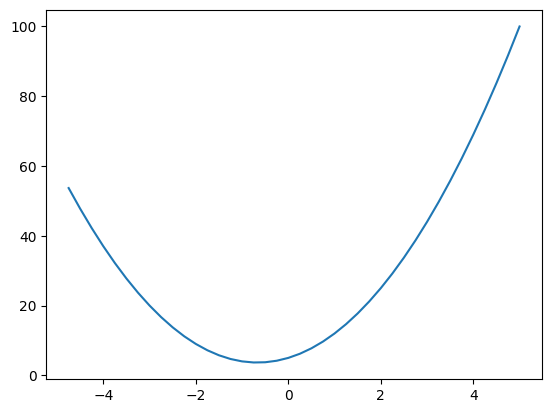

In [3]:
xs = np.arange(-5, 5, 0.25)
ys = f(xs)
ys

plt.plot(-xs, ys)

In [4]:
h = 0.000001
(f(xs+h)-f(xs)) / h

array([-33.999997  , -32.499997  , -30.99999701, -29.49999701,
       -27.999997  , -26.49999701, -24.99999701, -23.499997  ,
       -21.999997  , -20.49999701, -18.999997  , -17.499997  ,
       -15.999997  , -14.499997  , -12.999997  , -11.499997  ,
        -9.999997  ,  -8.499997  ,  -6.999997  ,  -5.499997  ,
        -3.999997  ,  -2.499997  ,  -0.999997  ,   0.500003  ,
         2.000003  ,   3.500003  ,   5.000003  ,   6.500003  ,
         8.000003  ,   9.500003  ,  11.000003  ,  12.500003  ,
        14.000003  ,  15.50000301,  17.000003  ,  18.50000299,
        20.00000299,  21.500003  ,  23.000003  ,  24.50000301])

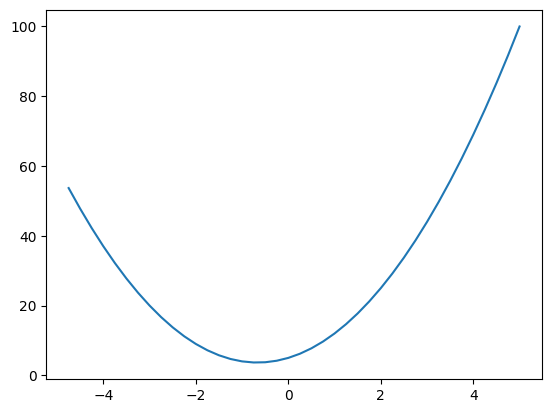

In [5]:
plt.plot(-xs, ys)

In [6]:
a = 2.0
b = -3.0
c = 10.0
d = a*b + c
print(d)

4.0


In [7]:
d1 = a*b + c
c += h
d2 = a*b + c

print('d1', d1)
print('d2', d2)
print('slope', (d2 - d1)/h)

d1 4.0
d2 4.000000999999999
slope 0.9999999992515995


In [8]:
c

10.000001

In [9]:
class Value:
  def __init__(self, data, _children=(), _op='', label = ''):
    self.data = data
    self._prev = set(_children)
    self._op = _op
    self.label = label
    self.grad = 0

  def __repr__(self):
    return f"Value(data={self.data})"

  def __add__(self, other):
    out = Value(self.data + other.data, (self, other), _op = "+")
    return out

  def __mul__(self, other):
    out = Value(self.data * other.data, (self, other),  _op = "*")
    return out

  def tanh(self):
    x = self.data
    # t = np.tanh(x)  # <-- Using numpy just for the numerical calculation, following is definition of tanh manually
    t = (math.exp(2*x) - 1) / (math.exp(2*x) + 1)
    out = Value(t, (self,), 'tanh')
    return out

In [10]:
a = Value(2.0,label='a')
b = Value(5.0, label='b')
c = a*b
c

Value(data=10.0)

In [11]:
c._prev

{Value(data=2.0), Value(data=5.0)}

In [12]:
c._op

'*'

In [13]:
from graphviz import Digraph

def trace(root):
    # builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # Added n.grad at the end of the formatting tuple below:
        dot.node(name = uid, label = "{%s | data %.4f | grad %.4f}" % (n.label, n.data, n.grad), shape='record')
        if n._op:
            dot.node(name = uid + n._op, label = n._op)
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

In [14]:
a = Value(2.0,label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label = 'c')
e = a*b; e.label = 'e'
d = e+c
d.label = 'd'
d

Value(data=4.0)

In [15]:
f = Value(-2.0, label='f')
L = d * f; L.label = 'L'
L


Value(data=-8.0)

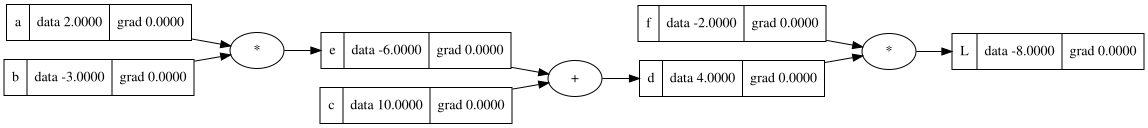

In [16]:
draw_dot(L)

In [17]:
L.grad = 1.0

In [18]:
def lol():

    h = 0.001

    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a*b; e.label = 'e'
    d = e + c; d.label = 'd'
    f = Value(-2.0, label='f')
    L = d * f; L.label = 'L'
    L1 = L.data

    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a*b; e.label = 'e'
    d = e + c; d.label = 'd'
    ## f changing wrt h
    f = Value(-2.0 + h, label='f')
    L = d * f; L.label = 'L'
    L2 = L.data

    print((L2 - L1)/h)

lol()

3.9999999999995595


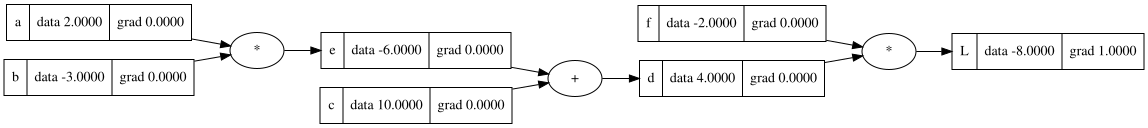

In [19]:
draw_dot(L)

In [20]:
# DL/DD
# L = d*f
# = f
# dl/df = d
# THUS

In [21]:
d.grad = f.data
f.grad = d.data

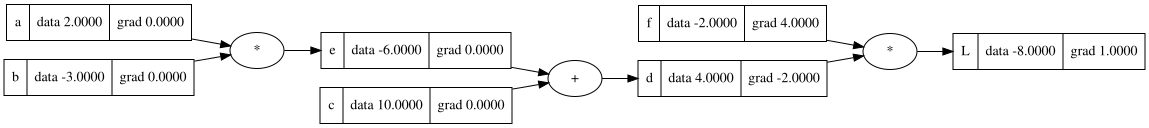

In [22]:
draw_dot(L)

In [23]:
def lol():

    h = 0.001

    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a*b; e.label = 'e'
    d = e + c; d.label = 'd'
    f = Value(-2.0, label='f')
    L = d * f; L.label = 'L'
    L1 = L.data

    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a*b; e.label = 'e'
    d = e + c; d.label = 'd'
    d.data += h  # <-- Nudging d by h
    f = Value(-2.0, label='f')
    L = d * f; L.label = 'L'
    L2 = L.data

    print((L2 - L1)/h)

lol()


-2.000000000000668


In [24]:
## dl/dc and dl/de by chain rule
# dl/dc = dl/dd * dd/dc
# dl/de = dl/dd * dd/de

# dl/dc = d.grad * dd/dc
# dl/de = d.grad * dd/de

# since d = e+c and derrivative of d wrt c would be 1
# same for dl/de

In [25]:
# Since dd/dc = 1.0 and dd/de = 1.0:
c.grad = d.grad * 1.0  # -2.0
e.grad = d.grad * 1.0  # -2.0

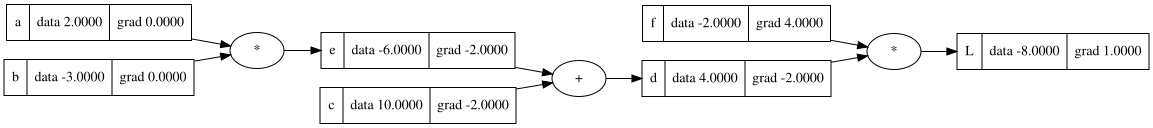

In [26]:
draw_dot(L)

In [27]:
def lol():

    h = 0.001

    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a*b; e.label = 'e'
    d = e + c; d.label = 'd'
    f = Value(-2.0, label='f')
    L = d * f; L.label = 'L'
    L1 = L.data

    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    # Nudging wrt c we should get -2
    c.data += h

    e = a*b; e.label = 'e'
    d = e + c; d.label = 'd'
    f = Value(-2.0, label='f')
    L = d * f; L.label = 'L'
    L2 = L.data

    print((L2 - L1)/h)

lol()


-1.9999999999988916


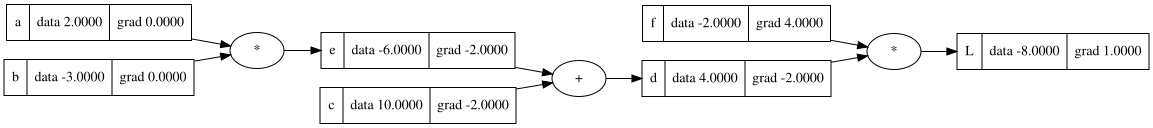

In [28]:
draw_dot(L)

In [29]:
# dl/da = e.grad * de/da
# since e = a*b so its derriv wrt a is simply b
# so dl/da = e.grad * b.data

# similarly dl/db = e.grad * a.data

In [30]:
a.grad = e.grad * b.data # -2 * -3
b.grad = e.grad * a.data # -2 * 2

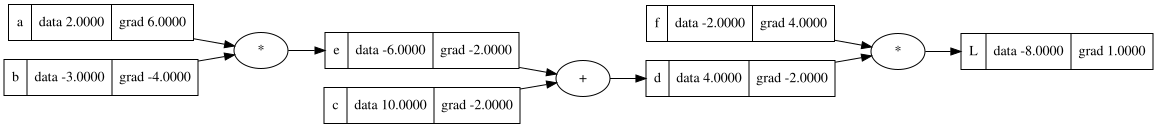

In [31]:
draw_dot(L)

#### verify for dl/da

In [32]:
def lol():

    h = 0.001

    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a*b; e.label = 'e'
    d = e + c; d.label = 'd'
    f = Value(-2.0, label='f')
    L = d * f; L.label = 'L'
    L1 = L.data

    a = Value(2.0, label='a')
    a.data += h
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')

    e = a*b; e.label = 'e'
    d = e + c; d.label = 'd'
    f = Value(-2.0, label='f')
    L = d * f; L.label = 'L'
    L2 = L.data

    print((L2 - L1)/h)

lol() # should equals actual value of dl/da which is 6


6.000000000000227


## **Summary of Manual Backpropagation (So Far)**

We have manually calculated and verified all partial derivatives (gradients) across our computational graph using the **chain rule**, verifying each step analytically and numerically via finite differences ($\text{slope} = \frac{L(x+h) - L(x)}{h}$):

### 1. Base Gradient
* $\frac{\partial L}{\partial L} = 1.0$ (`L.grad = 1.0`)

### 2. Backpropagation through Multiplication Node ($L = d \cdot f$)
Using the product rule derivative ($\frac{d}{dx}[x \cdot c] = c$):
* $\frac{\partial L}{\partial d} = f = -2.0$ (`d.grad = -2.0`)
* $\frac{\partial L}{\partial f} = d = 4.0$ (`f.grad = 4.0`)

### 3. Backpropagation through Addition Node ($d = e + c$)
Addition nodes simply pass the incoming gradient straight through ($\frac{\partial d}{\partial e} = 1$, $\frac{\partial d}{\partial c} = 1$):
* $\frac{\partial L}{\partial c} = \frac{\partial L}{\partial d} \cdot 1.0 = -2.0$ (`c.grad = -2.0`)
* $\frac{\partial L}{\partial e} = \frac{\partial L}{\partial d} \cdot 1.0 = -2.0$ (`e.grad = -2.0`)

### 4. Backpropagation through Multiplication Node ($e = a \cdot b$)
Applying the chain rule through $e$:
* $\frac{\partial L}{\partial a} = \frac{\partial L}{\partial e} \cdot \frac{\partial e}{\partial a} = \text{e.grad} \cdot b = (-2.0) \cdot (-3.0) = \mathbf{6.0}$ (`a.grad = 6.0`)
* $\frac{\partial L}{\partial b} = \frac{\partial L}{\partial e} \cdot \frac{\partial e}{\partial b} = \text{e.grad} \cdot a = (-2.0) \cdot (2.0) = \mathbf{-4.0}$ (`b.grad = -4.0`)

---

### Key Takeaways / Patterns
1. **Plus (`+`) nodes** act as **gradient distributors** — they route the incoming gradient to all inputs equally.
2. **Times (`*`) nodes** act as **gradient switchers** — they scale the incoming gradient by the value of the *other* input.

In [33]:
def lol():

  h = 0.001

  a = Value(2.0, label='a')
  b = Value(-3.0, label='b')
  c = Value(10.0, label='c')
  e = a*b; e.label = 'e'
  d = e + c; d.label = 'd'
  f = Value(-2.0, label='f')
  L = d * f; L.label = 'L'
  L1 = L.data

  a = Value(2.0, label='a')
  b = Value(-3.0, label='b')
  b.data += h
  c = Value(10.0, label='c')
  e = a*b; e.label = 'e'
  d = e + c; d.label = 'd'
  f = Value(-2.0, label='f')
  L = d * f; L.label = 'L'
  L2 = L.data

  print((L2 - L1)/h)

lol()

-3.9999999999995595


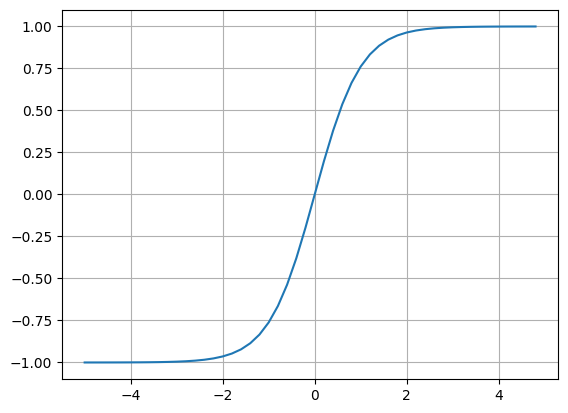

In [34]:
plt.plot(np.arange(-5,5,0.2), np.tanh(np.arange(-5,5,0.2))); plt.grid();

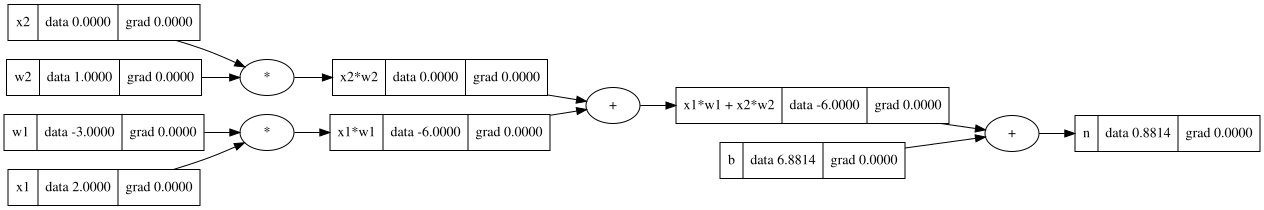

In [35]:
# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
draw_dot(n)

In [36]:
o = n.tanh(); o.label = 'o'

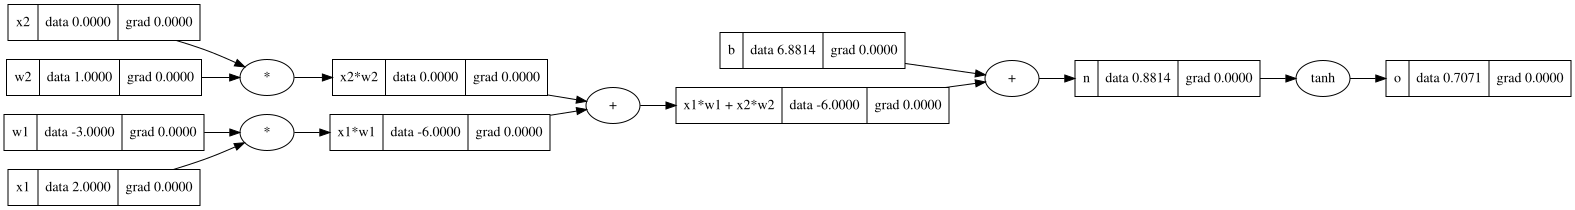

In [37]:
draw_dot(o)

In [38]:
o.grad = 1.0

In [39]:
# o = tanh(n)
# do/dn = 1 - (tanh(n))**2

# do/dn = 1 - o**2

1 - o.data**2

0.4999999999999999

In [40]:
n.grad = 0.5

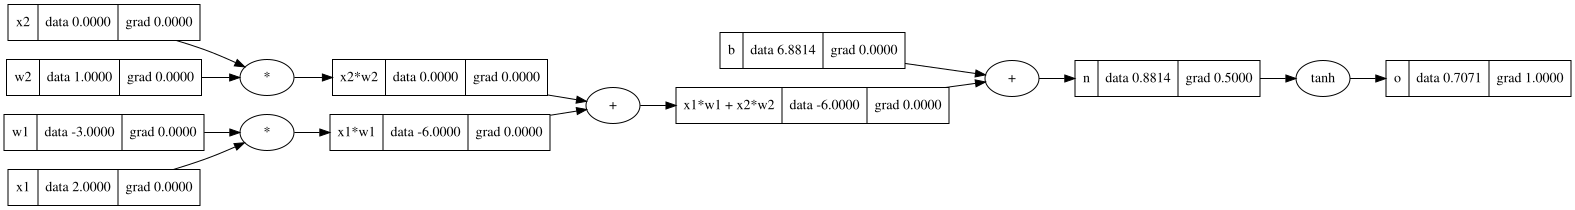

In [41]:
draw_dot(o)
# o represents the predicted output of the single neuron (the forward pass result).

In [42]:
# derrivative of o with respect to x1w1x2w2 and b

# do/d(x1w1x2w2) = do/dn * dn/d(x1w1x2w2)
#                = n.grad * dn/d(x1w1x2w2)
# since n = x1w1x2w2 + b, derriv of term x1w1x2w2 wrt itself is 1
#                = n.grad * 1

# do/db = n.grad * dn/db
#       = n.grad * 1

In [43]:
x1w1x2w2.grad = n.grad * 1
b.grad = n.grad * 1

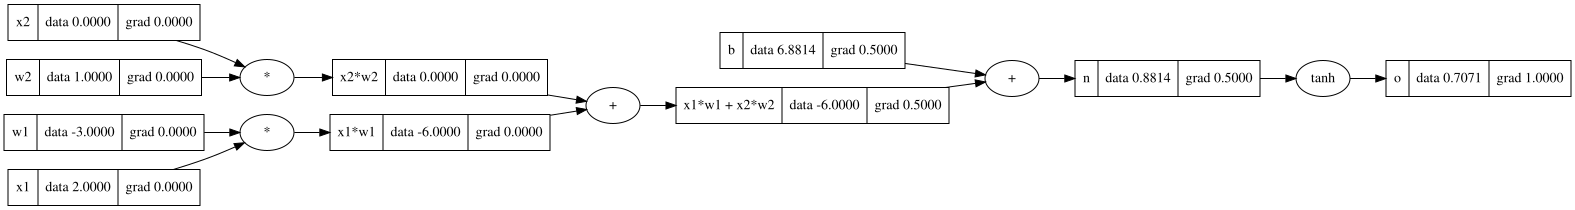

In [44]:
draw_dot(o)

In [45]:
# derrivative of o wrt x1w1 and x2w2
# do/dx1w1 = x1w1x2w2.grad * d(x1w1x2w2)/d(x1w1)   (remember x1w1x2w2 is x1w1+x2w2)
x1w1.grad = x1w1x2w2.grad * 1.0  # 0.5
x2w2.grad = x1w1x2w2.grad * 1.0  # 0.5

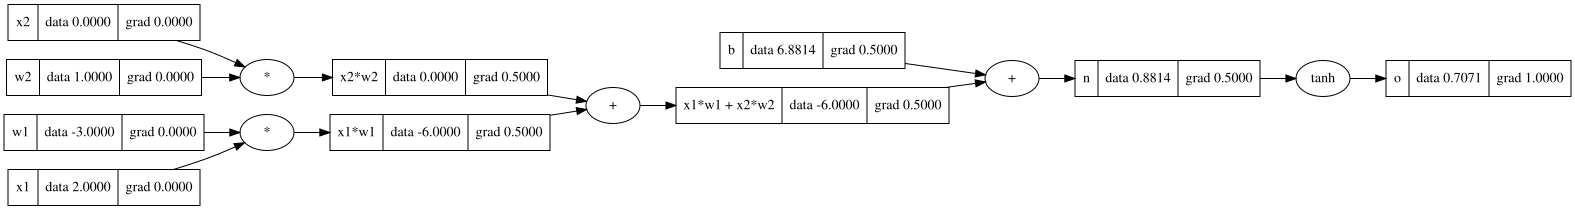

In [46]:
draw_dot(o)

In [47]:
# derivative of o wrt x2, x1, w2, w1

# For x2 and w2 (node: x2w2 = x2 * w2)
x2.grad = x2w2.grad * w2.data   # 0.5 * 1.0 = 0.5
w2.grad = x2w2.grad * x2.data   # 0.5 * 0.0 = 0.0

# For x1 and w1 (node: x1w1 = x1 * w1)
x1.grad = x1w1.grad * w1.data   # 0.5 * -3.0 = -1.5
w1.grad = x1w1.grad * x1.data   # 0.5 * 2.0 = 1.0

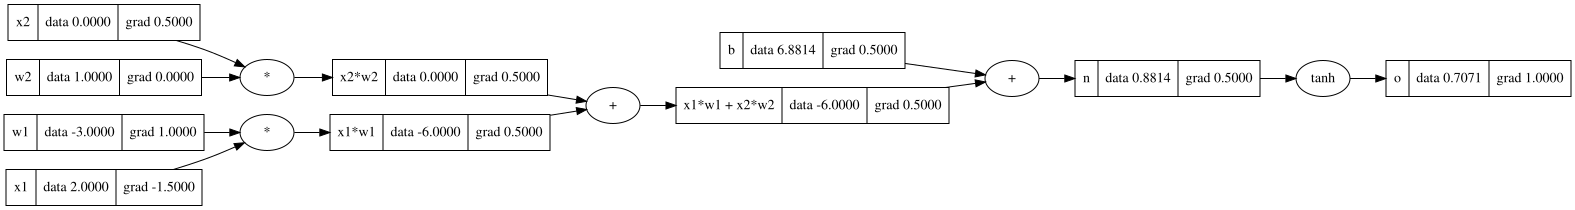

In [48]:
draw_dot(o)

## **Summary: Manual Backpropagation Through a Single Neuron**

We built a 2-input single neuron with a hyperbolic tangent ($\tanh$) activation function and manually computed the full backward pass using the chain rule.

---

### 1. Forward Pass Setup
* **Inputs:** $x_1 = 2.0$, $x_2 = 0.0$
* **Weights:** $w_1 = -3.0$, $w_2 = 1.0$
* **Bias:** $b = 6.8814$
* **Raw Neuron Output ($n$):**
  $$n = (x_1 \cdot w_1) + (x_2 \cdot w_2) + b = -6.0 + 0.0 + 6.8814 = 0.8814$$
* **Activated Output ($o$):**
  $$o = \tanh(n) \approx 0.7071$$

---

### 2. Manual Backward Pass Step-by-Step

#### Step A: Base Gradient
$$\frac{\partial o}{\partial o} = 1.0 \quad \text{(`o.grad = 1.0`)}$$

#### Step B: Activation Layer ($\tanh$)
Since $\frac{d}{dx}[\tanh(x)] = 1 - \tanh^2(x)$:
$$\frac{\partial o}{\partial n} = 1 - o^2 = 1 - (0.7071)^2 = 0.5 \quad \text{(`n.grad = 0.5`)}$$

#### Step C: Addition Nodes (Distribute Gradients)
Addition nodes route the incoming gradient unchanged ($\cdot 1.0$):
* $\frac{\partial o}{\partial (x_1 w_1 + x_2 w_2)} = 0.5 \cdot 1.0 = \mathbf{0.5}$ (`x1w1x2w2.grad = 0.5`)
* $\frac{\partial o}{\partial b} = 0.5 \cdot 1.0 = \mathbf{0.5}$ (`b.grad = 0.5`)
* $\frac{\partial o}{\partial (x_1 w_1)} = 0.5 \cdot 1.0 = \mathbf{0.5}$ (`x1w1.grad = 0.5`)
* $\frac{\partial o}{\partial (x_2 w_2)} = 0.5 \cdot 1.0 = \mathbf{0.5}$ (`x2w2.grad = 0.5`)

#### Step D: Input & Weight Leaf Nodes (Multiply & Swap Values)
Multiplication nodes scale the incoming gradient by the value of the paired input:
* **For $x_1$ and $w_1$:**
  $$\frac{\partial o}{\partial x_1} = \text{x1w1.grad} \cdot w_1 = 0.5 \cdot (-3.0) = \mathbf{-1.5} \quad \text{(`x1.grad = -1.5`)}$$
  $$\frac{\partial o}{\partial w_1} = \text{x1w1.grad} \cdot x_1 = 0.5 \cdot 2.0 = \mathbf{1.0} \quad \text{(`w1.grad = 1.0`)}$$

* **For $x_2$ and $w_2$:**
  $$\frac{\partial o}{\partial x_2} = \text{x2w2.grad} \cdot w_2 = 0.5 \cdot 1.0 = \mathbf{0.5} \quad \text{(`x2.grad = 0.5`)}$$
  $$\frac{\partial o}{\partial w_2} = \text{x2w2.grad} \cdot x_2 = 0.5 \cdot 0.0 = \mathbf{0.0} \quad \text{(`w2.grad = 0.0`)}$$

---

### Intuition Behind Gradients
* **$w_1.grad = 1.0$**: Increasing $w_1$ will increase the output $o$.
* **$x_1.grad = -1.5$**: Increasing $x_1$ will decrease the output $o$.
* **$w_2.grad = 0.0$**: Changing $w_2$ has no effect on $o$ right now because its corresponding input $x_2 = 0$.

## **Implementing the Backward Propagation**

In [49]:
## Using self.backward

In [50]:
class Value:
  def __init__(self, data, _children=(), _op='', label = ''):
    self.data = data
    self._prev = set(_children)
    self._op = _op
    self.label = label
    self.grad = 0
    self._backward = lambda : None

  def __repr__(self):
    return f"Value(data={self.data})"

  def __add__(self, other):
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data + other.data, (self, other), '+')

    def _backward():

      # In case of addition local derriv is 1 and outer func derrv
      # local(self) derrv * global derrv
      self.grad += 1.0 * out.grad
      # MATH FOR ADDITION WITH RESPECT TO 'OTHER':
      # Forward: out = self + other
      # Local Derivative: d(out)/d(other) = 1.0
      # Chain Rule: dL/d(other) = (dL/d(out)) * (d(out)/d(other))
      #                         = out.grad * 1.0
      other.grad += 1.0 * out.grad

    out._backward = _backward

    return out

  def __mul__(self, other):
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data * other.data, (self, other), '*')

    # In case of multiplication local derriv is other with which its  mult and outer func derrv
    def _backward():
      self.grad += other.data * out.grad
      other.grad += self.data * out.grad
    out._backward = _backward

    return out

  def tanh(self):
    x = self.data
    # t = np.tanh(x)  # <-- Using numpy just for the numerical calculation, following is definition of tanh manually
    t = (math.exp(2*x) - 1) / (math.exp(2*x) + 1)
    out = Value(t, (self,), 'tanh')

    def _backward():
      # Derivative of tanh(x) is 1 - tanh(x)^2
      # Since t = tanh(x), local derivative = (1 - t**2)
      self.grad += (1.0 - t**2) * out.grad

    out._backward = _backward

    return out

  def backward(self):

    topo = []
    visited = set()
    def build_topo(v):
      if v not in visited:
        visited.add(v)
        for child in v._prev:
          build_topo(child)
        topo.append(v)
    build_topo(self)

    self.grad = 1.0
    for node in reversed(topo):
      node._backward()

In [51]:
# Re-create the neuron nodes using the new Value class
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
b = Value(6.8813735870195432, label='b')

x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'

# Set base seed gradient for output
o.grad = 1.0

In [52]:
# 1. Backprop through tanh into n
o._backward()

# 2. Backprop through addition into x1w1x2w2 and b
n._backward()

# 3. Backprop through addition into x1w1 and x2w2
x1w1x2w2._backward()

# 4. Backprop through multiplications into leaf nodes (x1, w1, x2, w2)
x1w1._backward()
x2w2._backward()

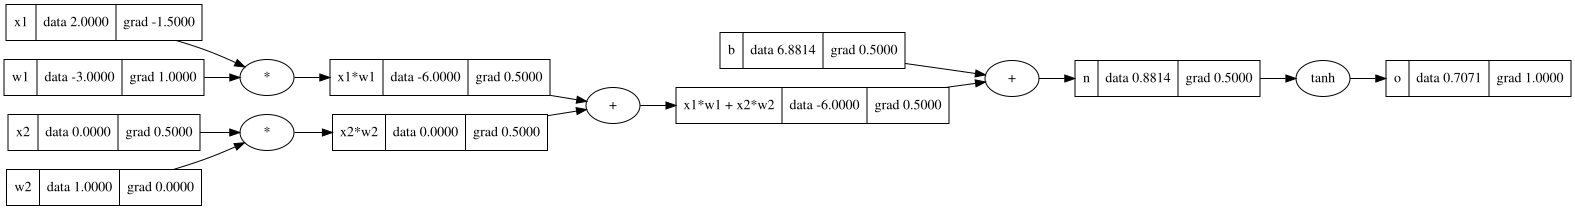

In [53]:
draw_dot(o)

In [54]:
# Re-create the neuron nodes using the new Value class
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
b = Value(6.8813735870195432, label='b')

x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'

# Set base seed gradient for output
o.grad = 1.0

In [55]:
# Reset all node gradients to zero
for node in [x1, x2, w1, w2, b, x1w1, x2w2, x1w1x2w2, n, o]:
    node.grad = 0.0

# Set output seed gradient back to 1.0
o.grad = 1.0

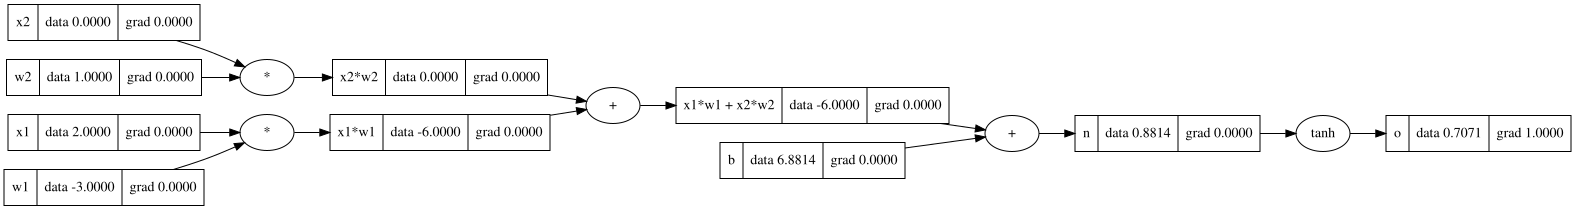

In [56]:
draw_dot(o)

In [57]:
o.backward()

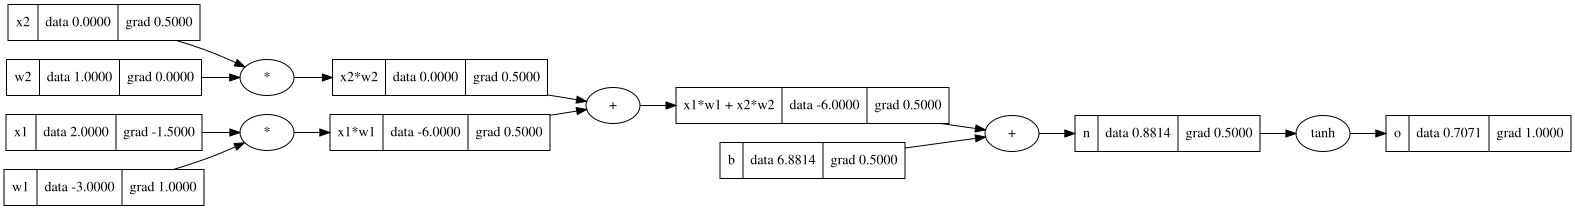

In [58]:
draw_dot(o)

In [59]:
# To guarantee that no node's _backward() is called prematurely
topo = []
visited = set()
def build_topo(v):
  if v not in visited:
    visited.add(v)
    for child in v._prev:
      build_topo(child)
    topo.append(v)
build_topo(o)
topo

[Value(data=6.881373587019543),
 Value(data=0.0),
 Value(data=1.0),
 Value(data=0.0),
 Value(data=2.0),
 Value(data=-3.0),
 Value(data=-6.0),
 Value(data=-6.0),
 Value(data=0.8813735870195432),
 Value(data=0.7071067811865476)]

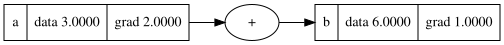

In [60]:
a = Value(3.0, label='a')
b = a + a   ; b.label = 'b'
b.backward()
draw_dot(b)

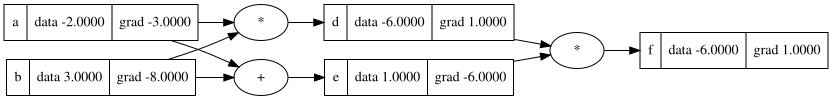

In [61]:
a = Value(-2.0, label='a')
b = Value(3.0, label='b')
d = a * b    ; d.label = 'd'
e = a + b    ; e.label = 'e'
f = d * e    ; f.label = 'f'

f.backward()

draw_dot(f)

In [62]:
a = Value(2.0)
a+1

Value(data=3.0)

## **Implemented Backpropagation so far!!!!**
---------------------------------

In [63]:
class Value:

  def __init__(self, data, _children=(), _op='', label=''):
    self.data = data
    self.grad = 0.0
    self._backward = lambda: None
    self._prev = set(_children)
    self._op = _op
    self.label = label

  def __repr__(self):
    return f"Value(data={self.data})"

  def __add__(self, other):
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data + other.data, (self, other), '+')

    def _backward():
      self.grad += 1.0 * out.grad
      other.grad += 1.0 * out.grad
    out._backward = _backward

    return out

  def __mul__(self, other):
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data * other.data, (self, other), '*')

    def _backward():
      self.grad += other.data * out.grad
      other.grad += self.data * out.grad
    out._backward = _backward

    return out

  def __pow__(self, other):
    assert isinstance(other, (int, float)), "only supporting int/float powers for now"
    out = Value(self.data**other, (self,), f'**{other}')

    def _backward():
        self.grad += other * (self.data ** (other - 1)) * out.grad
    out._backward = _backward

    return out

  def __rmul__(self, other): # other * self
    return self * other

  def __truediv__(self, other): # self / other
    return self * other**-1

  def __neg__(self): # -self
    return self * -1

  def __sub__(self, other): # self - other
    return self + (-other)

  def tanh(self):
    x = self.data
    t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
    out = Value(t, (self, ), 'tanh')

    def _backward():
      self.grad += (1 - t**2) * out.grad
    out._backward = _backward

    return out

  def exp(self):
    x = self.data
    out = Value(math.exp(x), (self, ), 'exp')

    def _backward():
      self.grad += out.data * out.grad
    out._backward = _backward

    return out


  def backward(self):

    topo = []
    visited = set()
    def build_topo(v):
      if v not in visited:
        visited.add(v)
        for child in v._prev:
          build_topo(child)
        topo.append(v)
    build_topo(self)

    self.grad = 1.0
    for node in reversed(topo):
      node._backward()

In [64]:
a = Value(2.0)
b = Value(5.0)
a-b

Value(data=-3.0)

In [65]:
# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'
o.backward()

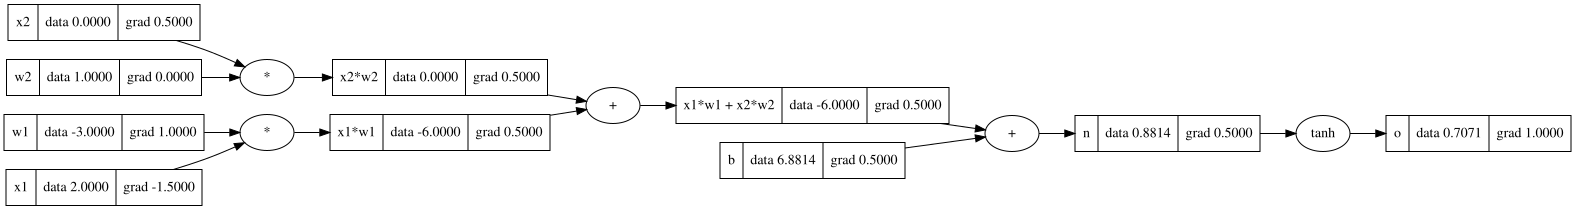

In [66]:
draw_dot(o)

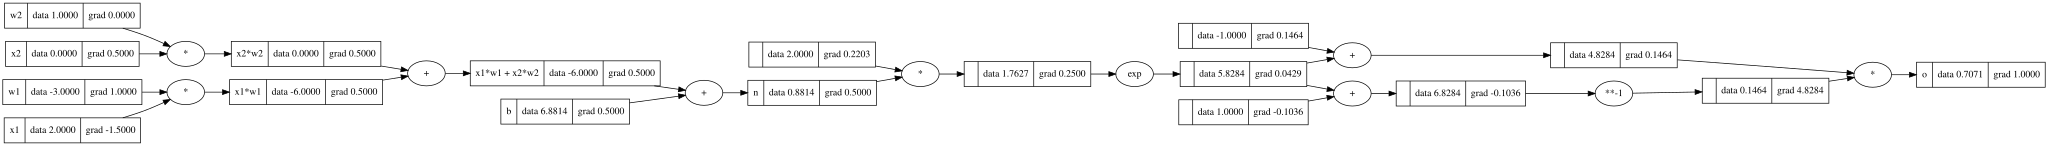

In [67]:
# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
# ----
e = (2*n).exp()
o = (e - 1) / (e + 1)
# ----
o.label = 'o'
o.backward()
draw_dot(o)

## We exercised with multiple Operations

## **Pytorch Version**

In [68]:
import torch

In [69]:
x1 = torch.Tensor([2.0]).double()                ; x1.requires_grad = True
x2 = torch.Tensor([0.0]).double()                ; x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double()               ; w1.requires_grad = True
w2 = torch.Tensor([1.0]).double()                ; w2.requires_grad = True
b = torch.Tensor([6.8813735870195432]).double()  ; b.requires_grad = True
n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print('---')
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())

0.7071066904050358
---
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737


In [70]:
o.data.item()

0.7071066904050358

In [71]:
class Neuron:
  def __init__(self, nin):
    self.w = [Value(random.uniform(-1,1)) for _ in range (nin)]
    self.b = Value(random.uniform(-1,1))

  def __call__(self, x):
    # w * x + b, calculates the linear combination
    # with __call__  neuron called directly like a function instead of n.forward(x)
    act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
    out = act.tanh()
    return out

  def parameters(self):
    # To access every learnt parameter
    return self.w + [self.b]



In [72]:
class Layer:

  def __init__(self, nin, nout):
    self.neurons = [Neuron(nin) for _ in range(nout)]

  def __call__(self, x):
    outs = [n(x) for n in self.neurons]
    return outs[0] if len(outs) == 1 else outs

  def parameters(self):
    return [p for neuron in self.neurons for p in neuron.parameters()]

In [73]:
import random

In [74]:
class Neuron:

  def __init__(self, nin):
    self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
    self.b = Value(random.uniform(-1,1))

  def __call__(self, x):
    # w * x + b
    act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
    out = act.tanh()
    return out

  def parameters(self):
    return self.w + [self.b]

class Layer:

  def __init__(self, nin, nout):
    self.neurons = [Neuron(nin) for _ in range(nout)]

  def __call__(self, x):
    outs = [n(x) for n in self.neurons]
    return outs[0] if len(outs) == 1 else outs

  def parameters(self):
    return [p for neuron in self.neurons for p in neuron.parameters()]

class MLP:

  def __init__(self, nin, nouts):
    sz = [nin] + nouts
    self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

  def __call__(self, x):
    for layer in self.layers:
      x = layer(x)
    return x

  def parameters(self):
    return [p for layer in self.layers for p in layer.parameters()]

In [75]:
x = [2.0, 3.0, -1.0]
n = MLP(3, [4, 4, 1])
n(x)

Value(data=0.09942149516107009)

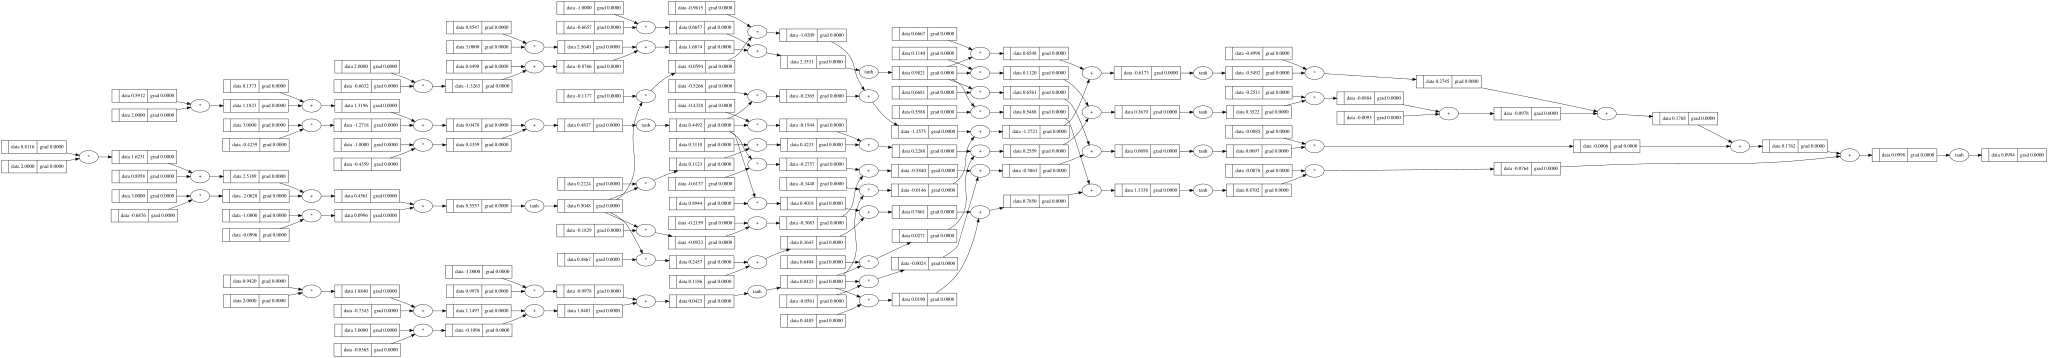

In [76]:
draw_dot(n(x))